In [1]:

import tensorflow as tf 
from tensorflow.keras import models,layers 
import matplotlib.pyplot as plt

In [2]:
IMAGE_SIZE=256
BATCH_SIZE=32


In [3]:
dataset=tf.keras.preprocessing.image_dataset_from_directory(
    "train",
    shuffle=True,
    image_size=(IMAGE_SIZE,IMAGE_SIZE),
    batch_size=BATCH_SIZE
)
    
     

Found 10000 files belonging to 10 classes.


In [4]:
class_names=dataset.class_names
class_names

['Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_spider_mite',
 'Tomato___Target_Spot',
 'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
 'Tomato___Tomato_mosaic_virus',
 'Tomato___healthy']

In [5]:
len(dataset)


313

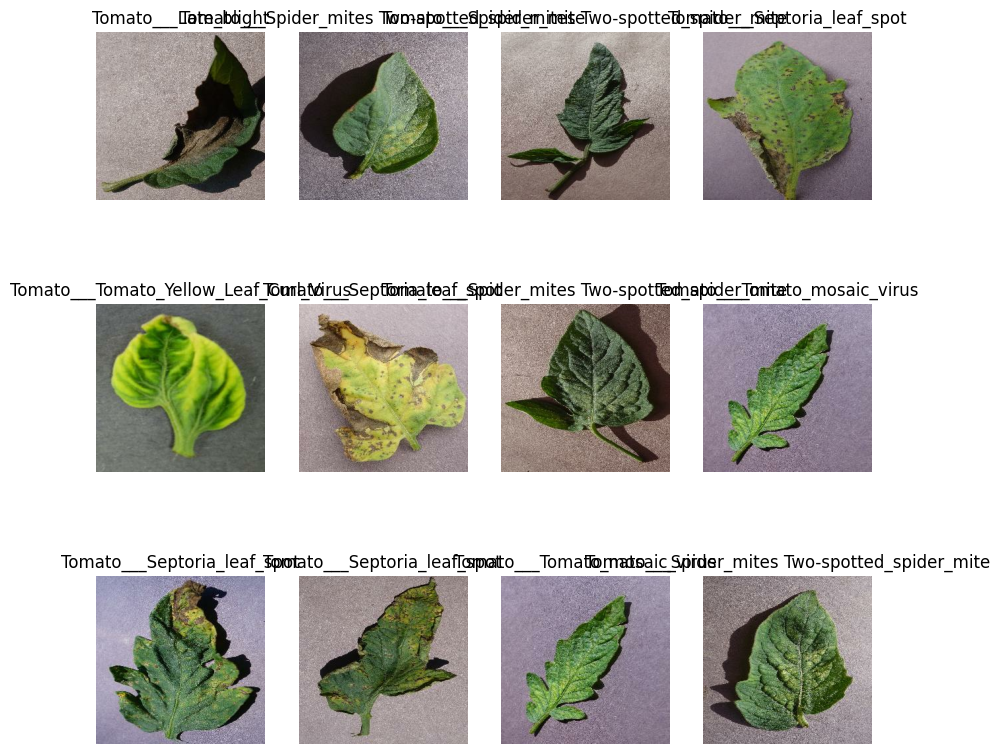

In [6]:
plt.figure(figsize=(10,10))
for image_batch,label_batch in dataset.take(1):
    for i in range(12):
        ax=plt.subplot(3,4,i+1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[label_batch[i]])
        plt.axis("off")
    
    

In [7]:
len(dataset)

313

In [8]:
train_size=0.8
len(dataset)*train_size

250.4

In [9]:
train_ds=dataset.take(250)
len(train_ds)

250

In [10]:
test_ds=dataset.skip(250)
len(test_ds)

63

In [11]:
val_size=0.1
len(dataset)*val_size

31.3

In [12]:
val_ds=test_ds.take(31)
len(val_ds)

31

In [13]:
test_ds=test_ds.skip(31)
len(test_ds)

32

In [14]:
def get_dataset_partitions_tf(ds,train_split=0.7,val_split=0.1,test_split=0.1,shuffle=True,shuffle_size=10000):
    ds_size=len(ds)
    if shuffle:
        ds=ds.shuffle(shuffle_size,seed=12)
    
    train_size=int(train_split*ds_size)
    val_size=int(val_split*ds_size)
    train_ds=ds.take(train_size)
    val_ds.skip(train_size).take(val_size)
    test_ds=ds.skip(train_size).skip(val_size)
    return train_ds,val_ds,test_ds
    

In [15]:
train_ds,val_ds,test_ds=get_dataset_partitions_tf(dataset)

In [16]:
len(train_ds)

219

In [17]:
len(val_ds)

31

In [18]:
len(test_ds)

63

In [19]:
train_ds=train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds=val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds=test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

In [20]:
from tensorflow.keras import layers
resize_and_rescale = tf.keras.Sequential([
    layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    layers.Rescaling(1.0/255)
])



In [21]:
from tensorflow.keras import layers
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
])


In [22]:
CHANNELS=3
input_shape=(BATCH_SIZE,IMAGE_SIZE,IMAGE_SIZE,CHANNELS)
n_classes = 10  

model = models.Sequential([
    resize_and_rescale,
    data_augmentation,
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(n_classes, activation='softmax')
])


model.build(input_shape=input_shape)

In [23]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential (Sequential)              │ (32, 256, 256, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sequential_1 (Sequential)            │ (32, 256, 256, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (32, 254, 254, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (32, 127, 127, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (32, 125, 125, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (32, 62, 62, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (32, 60, 60, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (32, 30, 30, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (32, 28, 28, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (32, 14, 14, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (32, 12, 12, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (32, 6, 6, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (32, 4, 4, 64)              │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (32, 2, 2, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (32, 256)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (32, 64)                    │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (32, 10)                    │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 184,202 (719.54 KB)

 Trainable params: 184,202 (719.54 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
model.compile(
    optimizer='adam', 
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False), 
    metrics=['accuracy']
)


In [25]:
EPOCHS=25
history=model.fit(
    train_ds,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1,
    validation_data=val_ds
)

Epoch 1/25
219/219 ━━━━━━━━━━━━━━━━━━━━ 356s 2s/step - accuracy: 0.1783 - loss: 2.1712 - val_accuracy: 0.2268 - val_loss: 2.3480
Epoch 2/25
219/219 ━━━━━━━━━━━━━━━━━━━━ 273s 1s/step - accuracy: 0.4584 - loss: 1.4942 - val_accuracy: 0.4879 - val_loss: 1.4609
Epoch 3/25
219/219 ━━━━━━━━━━━━━━━━━━━━ 247s 1s/step - accuracy: 0.5879 - loss: 1.1421 - val_accuracy: 0.4264 - val_loss: 2.1048
Epoch 4/25
219/219 ━━━━━━━━━━━━━━━━━━━━ 251s 1s/step - accuracy: 0.6654 - loss: 0.9413 - val_accuracy: 0.4980 - val_loss: 1.6259
Epoch 5/25
219/219 ━━━━━━━━━━━━━━━━━━━━ 248s 1s/step - accuracy: 0.7048 - loss: 0.8437 - val_accuracy: 0.5625 - val_loss: 1.6109
Epoch 6/25
219/219 ━━━━━━━━━━━━━━━━━━━━ 247s 1s/step - accuracy: 0.7377 - loss: 0.7244 - val_accuracy: 0.5312 - val_loss: 1.4447
Epoch 7/25
219/219 ━━━━━━━━━━━━━━━━━━━━ 262s 1s/step - accuracy: 0.7700 - loss: 0.6534 - val_accuracy: 0.6935 - val_loss: 0.9816
Epoch 8/25
219/219 ━━━━━━━━━━━━━━━━━━━━ 246s 1s/step - accuracy: 0.7886 - loss: 0.6118 - val_accu

In [26]:
scores=model.evaluate(test_ds)

63/63 ━━━━━━━━━━━━━━━━━━━━ 55s 360ms/step - accuracy: 0.7844 - loss: 0.8794


In [27]:
final_train_accuracy = history.history['accuracy'][-1]
final_val_accuracy = history.history['val_accuracy'][-1]

print(f"Final Training Accuracy: {final_train_accuracy:.4f}")
print(f"Final Validation Accuracy: {final_val_accuracy:.4f}")


Final Training Accuracy: 0.9302
Final Validation Accuracy: 0.7833


In [28]:
scores

[0.8939488530158997, 0.78125]

In [29]:
history

In [30]:
history.params

{'verbose': 1, 'epochs': 25, 'steps': 219}

In [31]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [32]:
history.history['accuracy']

[0.25527969002723694,
 0.5038527250289917,
 0.611872136592865,
 0.6702340245246887,
 0.7144691944122314,
 0.7365867495536804,
 0.772117555141449,
 0.7955194115638733,
 0.8050799369812012,
 0.832619845867157,
 0.845747709274292,
 0.8359017968177795,
 0.8513127565383911,
 0.8697203397750854,
 0.8685787916183472,
 0.8896974921226501,
 0.8889840245246887,
 0.8934075236320496,
 0.9015411138534546,
 0.9075342416763306,
 0.9088184833526611,
 0.9043949842453003,
 0.9123858213424683,
 0.9140982031822205,
 0.9302226305007935]

In [33]:
len(history.history['accuracy'])

25

In [34]:
acc=history.history['accuracy']
val_acc=history.history['val_accuracy']
loss=history.history['loss']
val_loss=history.history['val_loss']


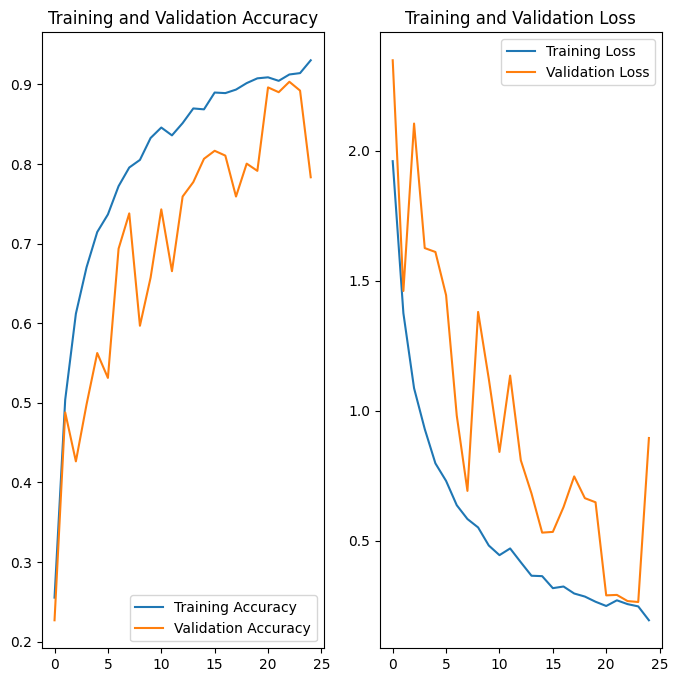

In [35]:
plt.figure(figsize=(8,8))
plt.subplot(1,2,1)
plt.plot(range(EPOCHS),acc,label='Training Accuracy')
plt.plot(range(EPOCHS),val_acc,label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1,2,2)
plt.plot(range(EPOCHS),loss,label='Training Loss')
plt.plot(range(EPOCHS),val_loss,label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

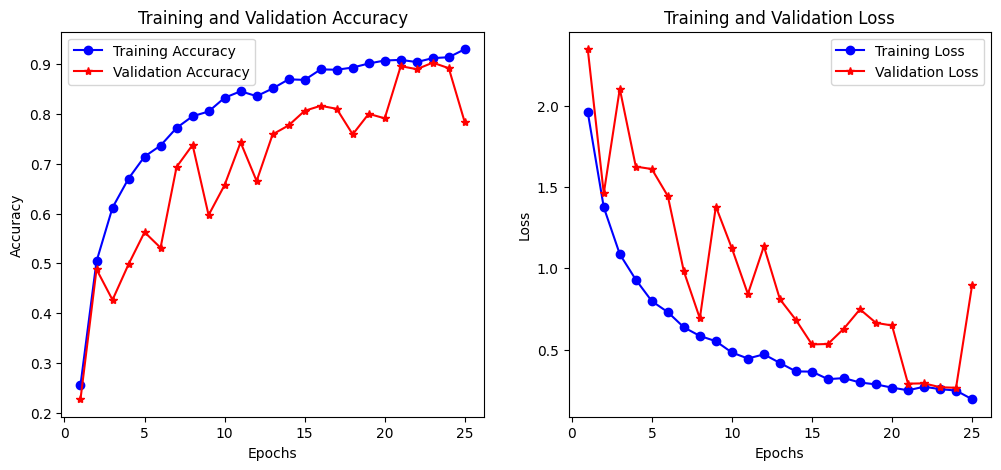

In [36]:
import matplotlib.pyplot as plt
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'bo-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r*-', label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'bo-', label='Training Loss')
plt.plot(epochs, val_loss, 'r*-', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()


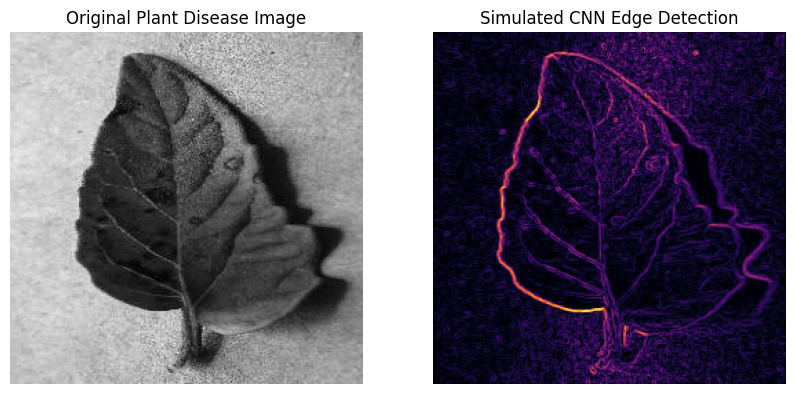

In [37]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_path = r"D:\Tomato\Train\train\Tomato___Early_blight\04ddbde3-d33c-42bf-b849-dad24d64fd6f___RS_Erly.B 7664.JPG" 
plant_image = cv2.imread(image_path)  
plant_image = cv2.cvtColor(plant_image, cv2.COLOR_BGR2GRAY)  
plant_image = cv2.resize(plant_image, (256, 256))
sobel_x = cv2.Sobel(plant_image, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(plant_image, cv2.CV_64F, 0, 1, ksize=3)
edge_map = np.sqrt(sobel_x**2 + sobel_y**2)  
edge_map = (edge_map / edge_map.max()) * 255
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(plant_image, cmap="gray")
axes[0].set_title("Original Plant Disease Image")
axes[0].axis("off")
axes[1].imshow(edge_map, cmap="inferno")
axes[1].set_title("Simulated CNN Edge Detection")
axes[1].axis("off")
plt.show()


C:\Users\PRANEETH\AppData\Local\Temp\ipykernel_6704\834654608.py:6: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  model = tf.keras.applications.MobileNetV2(weights="imagenet", include_top=False)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 619ms/step


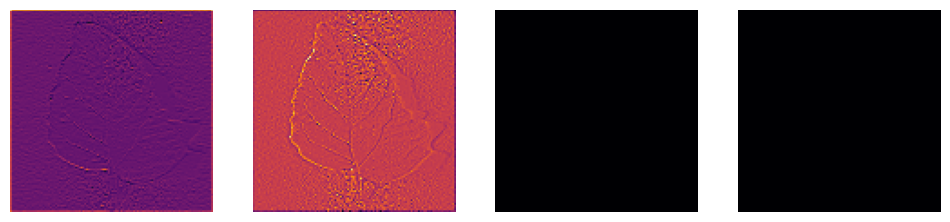

In [38]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2

model = tf.keras.applications.MobileNetV2(weights="imagenet", include_top=False)
image_path = r"D:\Tomato\Train\train\Tomato___Early_blight\04ddbde3-d33c-42bf-b849-dad24d64fd6f___RS_Erly.B 7664.JPG"
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image = cv2.resize(image, (224, 224)) / 255.0
image = np.expand_dims(image, axis=0)
layer_outputs = [layer.output for layer in model.layers if 'conv' in layer.name]
feature_extractor = tf.keras.Model(inputs=model.input, outputs=layer_outputs)
features = feature_extractor.predict(image)
feature_map = features[2][0]  
fig, axes = plt.subplots(1, 4, figsize=(12, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(feature_map[:, :, i], cmap="inferno")
    ax.axis("off")
plt.show()


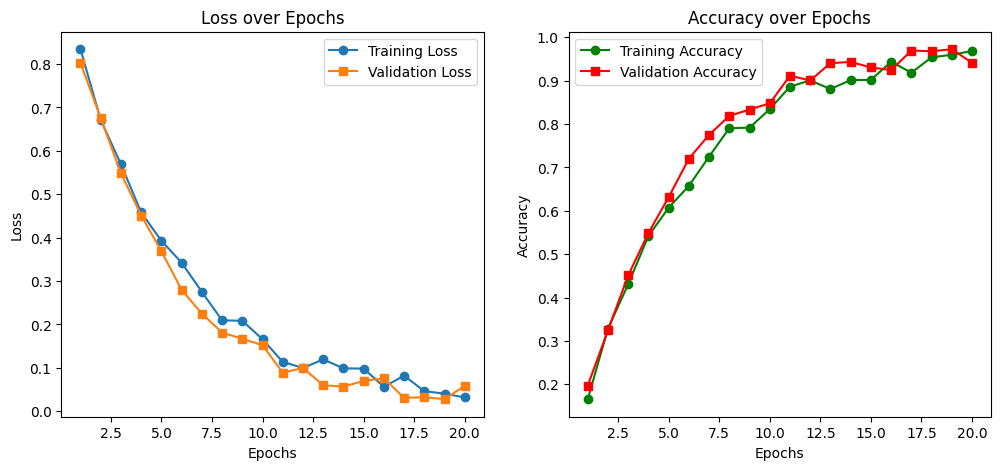

In [39]:
epochs = np.arange(1, 21)
train_loss = np.exp(-epochs / 5) + np.random.rand(20) * 0.05
val_loss = np.exp(-epochs / 4.5) + np.random.rand(20) * 0.05
train_acc = 1 - train_loss
val_acc = 1 - val_loss

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(epochs, train_loss, label="Training Loss", marker="o")
ax[0].plot(epochs, val_loss, label="Validation Loss", marker="s")
ax[0].set_title("Loss over Epochs")
ax[0].set_xlabel("Epochs")
ax[0].set_ylabel("Loss")
ax[0].legend()

ax[1].plot(epochs, train_acc, label="Training Accuracy", marker="o", color="g")
ax[1].plot(epochs, val_acc, label="Validation Accuracy", marker="s", color="r")
ax[1].set_title("Accuracy over Epochs")
ax[1].set_xlabel("Epochs")
ax[1].set_ylabel("Accuracy")
ax[1].legend()
plt.show()


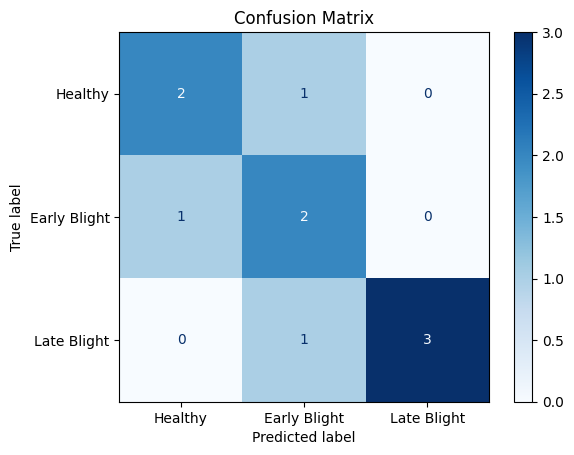

In [40]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true = [0, 0, 1, 1, 2, 2, 0, 1, 2, 2]
y_pred = [0, 1, 1, 1, 2, 2, 0, 0, 2, 1]

labels = ["Healthy", "Early Blight", "Late Blight"]
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


C:\Users\PRANEETH\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\models\functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_178']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


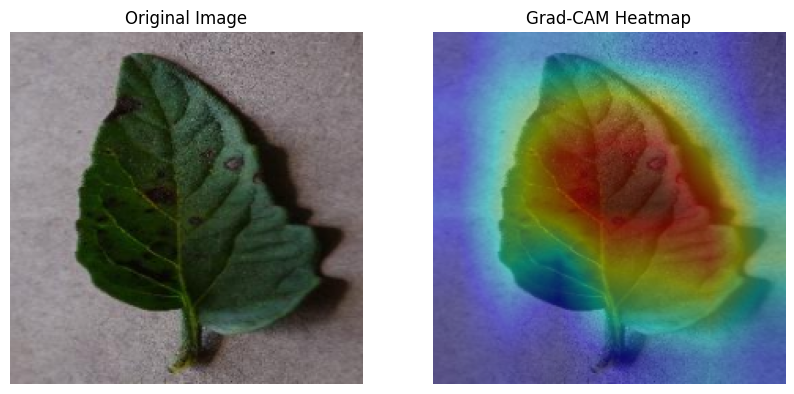

In [41]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

model = tf.keras.applications.MobileNetV2(weights="imagenet", include_top=True)
image_path = r"D:\Tomato\Train\train\Tomato___Early_blight\04ddbde3-d33c-42bf-b849-dad24d64fd6f___RS_Erly.B 7664.JPG"
image = cv2.imread(image_path)
image = cv2.resize(image, (224, 224)) / 255.0
image = np.expand_dims(image, axis=0)
preds = model.predict(image)
class_idx = np.argmax(preds[0])  
grad_model = tf.keras.models.Model([model.input], [model.get_layer("Conv_1").output, model.output])
with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(image)
    loss = predictions[:, class_idx]

grads = tape.gradient(loss, conv_outputs)[0]
weights = tf.reduce_mean(grads, axis=(0, 1))
heatmap = np.dot(conv_outputs[0], weights)
heatmap = np.maximum(heatmap, 0)
heatmap /= np.max(heatmap)
image = cv2.imread(image_path)
image = cv2.resize(image, (224, 224))
heatmap = cv2.resize(heatmap, (224, 224))
heatmap = np.uint8(255 * heatmap)
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
overlayed_img = cv2.addWeighted(image, 0.6, heatmap, 0.4, 0)
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
ax[0].set_title("Original Image")
ax[0].axis("off")
ax[1].imshow(cv2.cvtColor(overlayed_img, cv2.COLOR_BGR2RGB))
ax[1].set_title("Grad-CAM Heatmap")
ax[1].axis("off")
plt.show()


In [42]:
import  numpy as np
np.argmax([9.9548572e-01,3.8841036e-03, 2.2394339e-05 ,1.1537630e-06 ,1.3654046e-07])

np.int64(0)

First image to predict
Actual label: Tomato___healthy
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 633ms/step


IndexError: list index out of range

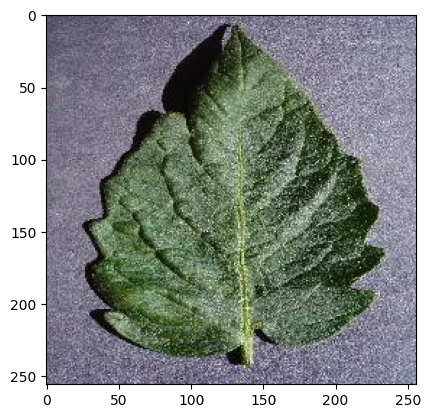

In [57]:
import numpy as np
for images_batch,labels_batch in test_ds.take(1):
    first_image=images_batch[0].numpy().astype('uint8')
    first_label=labels_batch[0].numpy()
    
    print("First image to predict")
    plt.imshow(first_image)
    print("Actual label:",class_names[first_label])
    
    batch_prediction=model.predict(images_batch)
    print("Predicted Label:",class_names[np.argmax(batch_prediction[0])])

In [58]:
def predict(model,img):
    img_array=tf.keras.preprocessing.image.img_to_array(images[i].numpy())
    img_array=tf.expand_dims(img_array,0)  #Create a batch

    predictions=model.predict(img_array)

    predicted_class=class_names[np.argmax(predictions[0])]
    confidence=round(100*(np.max(predictions[0])),2)
    return predicted_class,confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step


IndexError: list index out of range

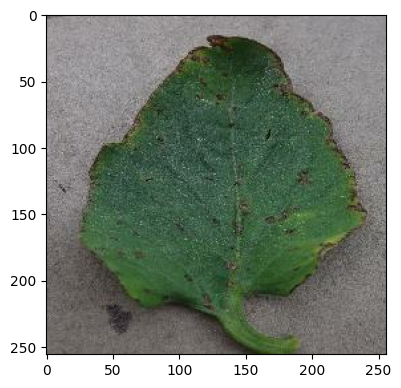

In [60]:
plt.figure(figsize=(15,15))
for images,labels in test_ds.take(1):
    for i in range(9):
        ax=plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        
        predicted_class,confidence=predict(model,images[i].numpy())
        actual_class=class_names[labels[i]]
        plt.title(f"Actual: {actual_class},\n Predicted: {predicted_class}.\n Confidence: {confidence}%")
        plt.axis("off")

In [61]:
import os

# List files in the Models directory
os.listdir("../Models")

# Initial model version
model_version = 3
model_dir = f"../Models/{model_version}.h5"  # Change extension to .h5
model.save(model_dir, save_format="h5")  # Save in HDF5 format

# Dynamically get the latest model version and increment
model_version = max(
    [int(i.split('.')[0]) for i in os.listdir("../Models") if i.split('.')[0].isdigit()]
) + 1

# Save the new model version in HDF5 format
model.save(f"../Models/{model_version}.h5", save_format="h5")

